# 04_baselines

**Goal:** Establish baseline models to prove the problem is non-trivial

This notebook:
- Implements simple baseline models (constant-probability, logistic regression, random forest)
- Uses walk-forward validation (no time leakage)
- Evaluates using Brier score and calibration plots
- Sets the bar that the GRU must beat

**Mindset:** Baselines are judges, not competitors. If GRU can't beat them, it's unjustified.

**Important:** No GRU, no deep learning, no sequence models, no hyperparameter tuning.


### Setup and Configuration

Imports all required libraries and defines the walk-forward validation configuration.

**Key parameters:**
- `train_days = 756` (~3 years): Training window size for walk-forward validation
- `val_days = 252` (~1 year): Validation window size
- `step_days = 252`: Step size equals validation window (non-overlapping validation periods)
- `seed = 42`: Fixed random seed for reproducibility

**Libraries used:**
- `LogisticRegression` / `LogisticRegressionCV`: Linear baseline with built-in cross-validated regularisation
- `RandomForestClassifier`: Nonlinear tree ensemble baseline
- `StandardScaler`: Z-score normalisation (fit on train only, applied to val)
- `PolynomialFeatures`: Generates interaction terms for logistic regression

**Why these baselines:** The three baselines form a hierarchy of model complexity:
1. Constant (no features) — the absolute floor
2. Logistic (linear + interactions) — tests if the problem is linearly separable
3. Random Forest (nonlinear) — tests if tree-based nonlinearity helps

The GRU in notebook 05 must beat ALL of these to justify its sequential architecture.

In [27]:
# Setup: Import dependencies and load configuration
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import RandomizedSearchCV
from sklearn.calibration import CalibratedClassifierCV
import warnings
warnings.filterwarnings('ignore')

# Project paths
PROJECT_ROOT = Path(".").resolve()
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
FIG_DIR = PROJECT_ROOT / "figures"

# Load configuration
CFG = {
    "primary_symbol": "^NDX",
    "horizon_days": 3,
    "drawdown_threshold": 0.03,
    "walkforward": {
        "train_days": 756,    # ~3 years
        "val_days": 252,      # ~1 year
        "step_days": 252      # Equal to val_days to avoid overlapping validation windows
    },  
    "seed": 42
}

# Helper to save figures consistently
def save_fig(name: str, dpi: int = 150):
    """Save current matplotlib figure to figures/ directory."""
    if not name.lower().endswith(".png"):
        name = f"{name}.png"
    out = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(out, dpi=dpi, bbox_inches="tight")
    return out

# Set seed for reproducibility
np.random.seed(CFG["seed"])

print("Setup complete")
print(f"Primary symbol: {CFG['primary_symbol']}")
print(f"Walk-forward: train={CFG['walkforward']['train_days']} days, val={CFG['walkforward']['val_days']} days, step={CFG['walkforward']['step_days']} days")


Setup complete
Primary symbol: ^NDX
Walk-forward: train=756 days, val=252 days, step=252 days


## 1. Load Features Dataset


### Load Feature Dataset

Loads the feature dataset produced by notebook 03 and prepares the feature matrix (X) and label vector (y).

**What happens:**
1. Loads the saved parquet/pickle file from `03_feature_operators`
2. Removes rows with NaN labels (last H days with no forward window)
3. Separates feature columns from metadata columns
4. Extracts VIX values for regime-specific modelling

**Why it is needed:** This cell establishes the exact same feature set that will be used by all three baselines AND the GRU, ensuring a fair comparison. The VIX array is extracted separately because regime-specific models need it for routing predictions to the appropriate sub-model.

**Methodological note:** The feature matrix includes regime indicators and interaction terms from notebook 03. This gives the linear models (logistic regression) access to regime-conditional effects without requiring separate model fits.

In [28]:
# Load features dataset
symbol = CFG["primary_symbol"]

features_file = DATA_DIR / f"features_{symbol}.parquet"
if not features_file.exists():
    features_file = DATA_DIR / f"features_{symbol}.pkl"

if not features_file.exists():
    raise FileNotFoundError(f"Features dataset not found: {features_file}. Run 03_feature_operators.ipynb first.")

print(f"Loading features dataset from: {features_file}")

if features_file.suffix == '.parquet':
    df = pd.read_parquet(features_file)
    # Set date column back as index if it was saved as a column
    for col in df.columns:
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            df = df.set_index(col)
            break
else:
    df = pd.read_pickle(features_file)

print(f"Loaded {len(df)} rows")
print(f"Date range: {df.index.min()} to {df.index.max()}")

# Remove rows with NaN labels (last H days)
H = CFG["horizon_days"]
df = df[df['label'].notna()].copy()
print(f"After removing NaN labels: {len(df)} rows")

# Extract feature columns (exclude OHLCV, label, drawdown, and date index)
exclude_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'label', 'drawdown']
feature_cols = [col for col in df.columns if col not in exclude_cols]

print(f"\nFeature columns ({len(feature_cols)}):")
print(feature_cols)

# Extract labels
y = df['label'].values
print(f"\nLabel distribution:")
print(f"  Class 0 (no event): {(y == 0).sum()} ({(y == 0).mean()*100:.2f}%)")
print(f"  Class 1 (event):    {(y == 1).sum()} ({(y == 1).mean()*100:.2f}%)")

# Extract features
X = df[feature_cols].values

# Extract VIX for regime-specific modeling (must be in dataframe)
if 'VIX' in df.columns:
    VIX = df['VIX'].values
    print(f"\nVIX data available: {len(VIX)} values, range [{VIX.min():.2f}, {VIX.max():.2f}]")
else:
    raise ValueError("VIX column not found. Regime-specific models require VIX data.")

print(f"\nFeature matrix shape: {X.shape}")
print(f"Features with NaN: {df[feature_cols].isnull().sum().sum()}")


Loading features dataset from: C:\Users\junio\Documents\TU821-4\FINAL YEAR PROJECT\data\features_^NDX.parquet
Loaded 6565 rows
Date range: 2000-01-03 00:00:00 to 2026-02-09 00:00:00
After removing NaN labels: 6562 rows

Feature columns (20):
['log_close', 'log_ret', 'ret_lag_1', 'ret_lag_2', 'ret_lag_3', 'ret_lag_4', 'ret_lag_5', 'VIX', 'VIX_5d_change', 'VIX_change_lag_1', 'VIX_change_lag_2', 'VIX_change_lag_3', 'realized_vol_5d', 'VIX_regime_low', 'VIX_regime_med', 'VIX_regime_high', 'ret_lag_1_x_VIX_low', 'ret_lag_1_x_VIX_high', 'realized_vol_5d_x_VIX_low', 'realized_vol_5d_x_VIX_high']

Label distribution:
  Class 0 (no event): 5700 (86.86%)
  Class 1 (event):    862 (13.14%)

VIX data available: 6562 values, range [9.14, 82.69]

Feature matrix shape: (6562, 20)
Features with NaN: 45


## 2. Walk-Forward Validation Setup


## Regime-Specific Model Helpers


### Regime-Specific Model Helpers

Defines utility functions for training and predicting with regime-specific models.

**Architecture:**
- `train_regime_specific_models()`: Splits training data by VIX regime (low < 15, med 15-25, high >= 25) and trains a separate model for each regime.
- `predict_regime_specific()`: Routes each validation sample to the appropriate regime model based on its VIX value at prediction time.

**Why regime-specific models:** Financial markets exhibit distinct statistical properties in different volatility regimes. A single model struggles to capture both calm-market and crisis-market dynamics. Training separate regime models allows each to specialise.

**Fallback logic:** If a regime has insufficient training data (< 50 samples or only one class), it falls back to the nearest available regime model. This prevents crashes during calm market periods where high-VIX samples are rare.

**Thesis context:** This regime-switching approach is a key methodological contribution — it gives the baselines their best chance of performing well, making the comparison against the GRU more rigorous.

In [29]:
# Helper functions for regime-specific modeling
def train_regime_specific_models(X_train, y_train, VIX_train, model_class, **model_params):
    """Train separate models for low/med/high VIX regimes."""
    models = {}
    
    # Define regime thresholds
    regimes = {
        'low': (0, 15),
        'med': (15, 25),
        'high': (25, 100)
    }
    
    for regime_name, (vix_min, vix_max) in regimes.items():
        # Filter training data for this regime
        mask = (VIX_train >= vix_min) & (VIX_train < vix_max)
        X_regime = X_train[mask]
        y_regime = y_train[mask]
        
        # Skip if not enough data
        if len(y_regime) < 50 or len(np.unique(y_regime)) < 2:
            print(f"  Skipping {regime_name} regime (insufficient data: {len(y_regime)} samples)")
            models[regime_name] = None
            continue
        
        # Train model for this regime
        model = model_class(**model_params)
        model.fit(X_regime, y_regime)
        models[regime_name] = model
        
        print(f"  {regime_name} regime: {len(y_regime)} samples, {y_regime.mean():.2%} event rate")
    
    return models

def predict_regime_specific(models, X_val, VIX_val):
    """Predict using regime-appropriate model."""
    predictions = np.zeros(len(X_val))
    
    for i in range(len(X_val)):
        vix = VIX_val[i]
        
        # Determine regime
        if vix < 15:
            regime = 'low'
        elif vix < 25:
            regime = 'med'
        else:
            regime = 'high'
        
        # Use appropriate model (fallback to medium if regime model unavailable)
        model = models.get(regime) or models.get('med') or models.get('high') or models.get('low')
        
        if model is not None:
            predictions[i] = model.predict_proba(X_val[i:i+1])[0, 1]
        else:
            # Fallback to base rate if no model available
            predictions[i] = 0.08  # Approximate base rate
    
    return predictions

# Helper functions for regime-specific modeling
def train_regime_specific_models(X_train, y_train, VIX_train, model_class, **model_params):
    """Train separate models for low/med/high VIX regimes."""
    models = {}
    
    # Define regime thresholds
    regimes = {
        'low': (0, 15),
        'med': (15, 25),
        'high': (25, 100)
    }
    
    for regime_name, (vix_min, vix_max) in regimes.items():
        # Filter training data for this regime
        mask = (VIX_train >= vix_min) & (VIX_train < vix_max)
        X_regime = X_train[mask]
        y_regime = y_train[mask]
        
        # Skip if not enough data
        if len(y_regime) < 50 or len(np.unique(y_regime)) < 2:
            print(f"  Skipping {regime_name} regime (insufficient data: {len(y_regime)} samples)")
            models[regime_name] = None
            continue
        
        # Train model for this regime
        model = model_class(**model_params)
        model.fit(X_regime, y_regime)
        models[regime_name] = model
        
        print(f"  {regime_name} regime: {len(y_regime)} samples, {y_regime.mean():.2%} event rate")
    
    return models

def predict_regime_specific(models, X_val, VIX_val):
    """Predict using regime-appropriate model."""
    predictions = np.zeros(len(X_val))
    
    for i in range(len(X_val)):
        vix = VIX_val[i]
        
        # Determine regime
        if vix < 15:
            regime = 'low'
        elif vix < 25:
            regime = 'med'
        else:
            regime = 'high'
        
        # Use appropriate model (fallback to medium if regime model unavailable)
        model = models.get(regime) or models.get('med') or models.get('high') or models.get('low')
        
        if model is not None:
            predictions[i] = model.predict_proba(X_val[i:i+1])[0, 1]
        else:
            # Fallback to base rate if no model available
            predictions[i] = 0.08  # Approximate base rate
    
    return predictions

print("Regime-specific model helpers defined")


Regime-specific model helpers defined


### Walk-Forward Validation Split Generation

Implements the walk-forward (expanding or sliding window) validation scheme that prevents temporal data leakage.

**How it works:**
- Starting from the beginning of the dataset, create training windows of 756 days (~3 years)
- The validation window immediately follows: the next 252 days (~1 year)
- Slide forward by 252 days (step_days) to create the next split
- Continue until the validation window would exceed the dataset

**Why walk-forward (not k-fold):** Standard k-fold cross-validation randomly shuffles data, which causes future data to leak into training. Walk-forward validation respects temporal ordering: training always precedes validation chronologically. This mirrors how the model would be used in production.

**Why train=756, val=252, step=252:** 
- 3 years of training captures multiple market regimes (bull, bear, sideways)
- 1 year of validation is long enough to include rare events
- step=val ensures non-overlapping validation periods (no double-counting)

**Thesis context:** This validation scheme is described in the methodology chapter and is consistent across all model evaluations (baselines and GRU).

In [30]:
# Walk-forward validation setup
# Generate splits based on row indices (chronological, no shuffling)

def walkforward_splits(n: int, train_days: int, val_days: int, step_days: int):
    # Sliding window approach: each split advances by step_days
    # This creates non-overlapping validation windows when step_days == val_days
    """Generate walk-forward splits based on number of rows."""
    splits = []
    start = 0
    while True:
        train_start = start
        train_end = train_start + train_days
        val_start = train_end
        val_end = val_start + val_days
        if val_end > n:
            break
        splits.append({
            "train_start": train_start,
            "train_end": train_end,
            "val_start": val_start,
            "val_end": val_end
        })
        start += step_days
    return splits

train_days = CFG["walkforward"]["train_days"]
val_days = CFG["walkforward"]["val_days"]
step_days = CFG["walkforward"]["step_days"]

splits = walkforward_splits(len(df), train_days, val_days, step_days)

print(f"Generated {len(splits)} walk-forward splits")
print(f"Train window: {train_days} days (~{train_days/252:.1f} years)")
print(f"Validation window: {val_days} days (~{val_days/252:.1f} years)")
print(f"Step size: {step_days} days (~{step_days/252:.2f} years)")

print(f"\nFirst split:")
print(f"  Train: rows {splits[0]['train_start']}-{splits[0]['train_end']} ({df.index[splits[0]['train_start']]} to {df.index[splits[0]['train_end']-1]})")
print(f"  Val:   rows {splits[0]['val_start']}-{splits[0]['val_end']} ({df.index[splits[0]['val_start']]} to {df.index[splits[0]['val_end']-1]})")

print(f"\nLast split:")
print(f"  Train: rows {splits[-1]['train_start']}-{splits[-1]['train_end']} ({df.index[splits[-1]['train_start']]} to {df.index[splits[-1]['train_end']-1]})")
print(f"  Val:   rows {splits[-1]['val_start']}-{splits[-1]['val_end']} ({df.index[splits[-1]['val_start']]} to {df.index[splits[-1]['val_end']-1]})")


Generated 23 walk-forward splits
Train window: 756 days (~3.0 years)
Validation window: 252 days (~1.0 years)
Step size: 252 days (~1.00 years)

First split:
  Train: rows 0-756 (2000-01-03 00:00:00 to 2003-01-07 00:00:00)
  Val:   rows 756-1008 (2003-01-08 00:00:00 to 2004-01-07 00:00:00)

Last split:
  Train: rows 5544-6300 (2022-01-13 00:00:00 to 2025-01-17 00:00:00)
  Val:   rows 6300-6552 (2025-01-21 00:00:00 to 2026-01-21 00:00:00)


## 3. Baseline 1: Constant-Probability Baseline


### Baseline 1: Constant-Probability Model

The simplest possible baseline — predicts the historical event rate from training data as the probability for every validation sample.

**How it works:**
- For each walk-forward split, compute p = (number of events in training set) / (training set size)
- Predict p for every sample in the validation set
- Compute Brier score: mean((p - actual)^2)

**Why it is needed:** This is the "idiot model" that any useful predictor must beat. If a sophisticated model cannot outperform simply predicting the base rate, it adds no value. The constant baseline's Brier score equals p*(1-p) when training and validation event rates match — deviations from this reveal distribution shift across time.

**Brier Score interpretation:** Brier score ranges from 0 (perfect) to 1 (worst). For rare events (p ~ 0.08), the constant baseline achieves approximately 0.08 * 0.92 = 0.074. Any improvement below this represents genuine predictive skill.

**Implementation detail:** NaN filtering is applied identically to all baselines to ensure comparable sample counts across models.

In [31]:
# Constant-probability baseline: "idiot model"
# Always predicts the historical event rate from training data
# No training needed - just math

print("=" * 60)
print("BASELINE 1: Constant-Probability")
print("=" * 60)

constant_results = []
constant_brier_per_split = []  # Store Brier score per split
constant_split_indices = []  # Track which split indices were processed
constant_event_rates_train = []  # Store train event rates per fold
constant_event_rates_val = []  # Store validation event rates per fold
fold_dates = []  # Store date ranges for each fold (list indexed by position)
fold_dates_dict = {}  # Store date ranges indexed by split_idx for easy lookup

for split_idx, split in enumerate(splits):
    # Get train and test indices
    train_idx = np.arange(split['train_start'], split['train_end'])
    val_idx = np.arange(split['val_start'], split['val_end'])
    
    # Extract train/test data
    X_train = X[train_idx]
    y_train = y[train_idx]
    X_val = X[val_idx]
    y_val = y[val_idx]
    
    # CRITICAL: Use same NaN filtering as other models
    # Remove rows with NaN features (from warm-up period)
    train_valid = ~np.isnan(X_train).any(axis=1)
    val_valid = ~np.isnan(X_val).any(axis=1)
    
    # Filter training data (for computing event rate)
    X_train = X_train[train_valid]
    y_train = y_train[train_valid]
    
    # Filter validation data (same as other models)
    y_val = y_val[val_valid]
    val_dates = df.index[val_idx][val_valid]  # Keep track of valid dates
    
    # Skip if no valid training or validation data
    if len(y_train) == 0 or len(y_val) == 0:
        continue
    
    # Compute historical event rate from training data
    # This is the maximum likelihood estimate of P(event) under i.i.d. assumption
    p_constant = y_train.mean()
    
    # Predict same probability for all test samples
    val_pred = np.full(len(y_val), p_constant)
    
    # Compute Brier score for this split: mean((predicted - actual)^2)
    # The Brier score for a constant predictor theoretically equals p*(1-p) + (p - p_val)^2
    # where p_val is the validation event rate (measures distribution shift penalty)
    brier_score = np.mean((val_pred - y_val) ** 2)
    constant_brier_per_split.append(brier_score)
    constant_split_indices.append(split_idx)  # Track which split this is
    
    # Track event rates
    train_event_rate = y_train.mean() if len(y_train) > 0 else 0.0
    val_event_rate = y_val.mean() if len(y_val) > 0 else 0.0
    constant_event_rates_train.append(train_event_rate)
    constant_event_rates_val.append(val_event_rate)
    
    # Store date ranges for this fold
    train_start_date = df.index[split['train_start']]
    train_end_date = df.index[split['train_end'] - 1]
    val_start_date = df.index[split['val_start']]
    val_end_date = df.index[split['val_end'] - 1]
    date_info = {
        'train_start': train_start_date,
        'train_end': train_end_date,
        'val_start': val_start_date,
        'val_end': val_end_date
    }
    fold_dates.append(date_info)  # List for backward compatibility
    fold_dates_dict[split_idx] = date_info  # Dictionary indexed by split_idx
    
    # Store results (only for valid samples)
    for i, (date, pred, actual) in enumerate(zip(val_dates, val_pred, y_val)):
        constant_results.append({
            'split_index': split_idx,
            'model_name': 'constant',
            'date': date,
            'predicted_prob': pred,
            'actual_label': actual,
            'brier_score': (pred - actual) ** 2
        })
    
    if split_idx == 0:
        print(f"\nSplit {split_idx}:")
        print(f"  Train event rate: {p_constant:.4f} ({p_constant*100:.2f}%)")
        print(f"  Test samples: {len(y_val)}")
        print(f"  Brier score: {brier_score:.6f}")

# Aggregate Brier scores: compute mean and std ACROSS SPLITS (not across samples)
constant_df = pd.DataFrame(constant_results)
mean_brier = np.mean(constant_brier_per_split)
std_brier = np.std(constant_brier_per_split)

print(f"\nAggregated results:")
print(f"  Mean Brier score (across splits): {mean_brier:.6f}")
print(f"  Std Brier score (across splits):  {std_brier:.6f}")
print(f"  Number of splits: {len(constant_brier_per_split)}")
print(f"  Total predictions: {len(constant_df)}")


BASELINE 1: Constant-Probability

Split 0:
  Train event rate: 0.4400 (44.00%)
  Test samples: 252
  Brier score: 0.206457

Aggregated results:
  Mean Brier score (across splits): 0.093741
  Std Brier score (across splits):  0.064341
  Number of splits: 23
  Total predictions: 5796


## 4. Baseline 2: Logistic Regression


### Baseline 2: Logistic Regression with Polynomial Features and Regime Models

The linear baseline that tests whether the problem has any linear structure exploitable by features.

**How it works:**
1. Standard-scale features (fit on training data only — critical to avoid leakage)
2. Generate polynomial interaction terms (degree=2, interactions only — no squared terms)
3. Train regime-specific LogisticRegressionCV models (with built-in L2 regularisation via CV)
4. Predict using regime-appropriate model based on validation-time VIX

**Why polynomial features:** Pure logistic regression can only learn linear decision boundaries. Adding interaction terms (feature_i * feature_j) allows it to capture multiplicative effects (e.g., "high volatility AND negative returns together signal danger"). This gives the linear model its best chance.

**Why LogisticRegressionCV:** Uses internal 5-fold cross-validation (within the training set) to select the regularisation strength (C parameter). This prevents overfitting without requiring a separate hyperparameter tuning loop.

**Scoring:** Uses `neg_brier_score` as the CV objective — directly optimising for calibrated probability estimation rather than classification accuracy.

**Thesis context:** If logistic regression beats the constant baseline significantly, it proves the features carry predictive information. If it doesn't, the features may need revision.

In [32]:
# Logistic Regression: The honest linear model
# Most important baseline - tests if problem is linearly separable

print("=" * 60)
print("BASELINE 2: Logistic Regression")
print("=" * 60)

logistic_results = []
logistic_brier_per_split = []  # Store Brier score per split
logistic_split_indices = []  # Track which split indices were processed
logistic_event_rates_train = []  # Store train event rates per fold
logistic_event_rates_val = []  # Store validation event rates per fold

for split_idx, split in enumerate(splits):
    # Get train and test indices
    train_idx = np.arange(split['train_start'], split['train_end'])
    val_idx = np.arange(split['val_start'], split['val_end'])
    
    # Extract train/test data
    X_train = X[train_idx]
    y_train = y[train_idx]
    X_val = X[val_idx]
    y_val = y[val_idx]
    VIX_train = VIX[train_idx]
    VIX_val = VIX[val_idx]
    
    # Remove rows with NaN features (from warm-up period)
    train_valid = ~np.isnan(X_train).any(axis=1)
    val_valid = ~np.isnan(X_val).any(axis=1)
    
    X_train = X_train[train_valid]
    y_train = y_train[train_valid]
    VIX_train = VIX_train[train_valid]
    X_val = X_val[val_valid]
    y_val = y_val[val_valid]
    VIX_val = VIX_val[val_valid]
    val_dates = df.index[val_idx][val_valid]  # Keep track of valid dates
    
    # Skip if no valid training data
    if len(X_train) == 0 or len(X_val) == 0:
        continue
    
    # CRITICAL: Check if training data has at least 2 classes
    unique_classes = np.unique(y_train)
    if len(unique_classes) < 2:
        print(f"  Split {split_idx}: Skipping - training data has only one class: {unique_classes[0]}")
        continue
    
    # CRITICAL: Scaler fitted on training data only to prevent information leakage
    # Validation data is transformed using training statistics (mean, std)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    
    # Scale test data using same scaler (fit on train only)
    X_val_scaled = scaler.transform(X_val)
    
    # Add polynomial features (interaction terms only, degree=2)
    # This expands K features to K + K*(K-1)/2 interaction features
    # Allows logistic regression to learn XOR-like patterns
    # This allows the model to learn non-linear patterns without exploding feature space
    poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_val_poly = poly.transform(X_val_scaled)
    
    # Train regime-specific models
    if split_idx == 0:
        print(f"\nSplit {split_idx}: Training regime-specific Logistic Regression models")
    
    # Define model parameters
    model_params = {
        'Cs': 10,
        'cv': 5,
        'scoring': 'neg_brier_score',
        'max_iter': 1000,
        'random_state': CFG["seed"],
        'n_jobs': 1
    }
    
    # Train separate models for each VIX regime
    lr_models = train_regime_specific_models(
        X_train_poly, y_train, VIX_train,
        LogisticRegressionCV,
        **model_params
    )
    
    # Predict using regime-appropriate models
    val_pred_proba = predict_regime_specific(lr_models, X_val_poly, VIX_val)
    # Compute Brier score for this split
    brier_score = np.mean((val_pred_proba - y_val) ** 2)
    logistic_brier_per_split.append(brier_score)
    logistic_split_indices.append(split_idx)  # Track which split this is
    
    # Track event rates
    train_event_rate = y_train.mean() if len(y_train) > 0 else 0.0
    val_event_rate = y_val.mean() if len(y_val) > 0 else 0.0
    logistic_event_rates_train.append(train_event_rate)
    logistic_event_rates_val.append(val_event_rate)
    
    # Store results (only for valid samples)
    for i, (date, pred, actual) in enumerate(zip(val_dates, val_pred_proba, y_val)):
        logistic_results.append({
            'split_index': split_idx,
            'model_name': 'logistic',
            'date': date,
            'predicted_prob': pred,
            'actual_label': actual,
            'brier_score': (pred - actual) ** 2
        })
    
    if split_idx == 0:
        print(f"\nSplit {split_idx}:")
        print(f"  Train samples: {len(y_train)}")
        print(f"  Test samples: {len(y_val)}")
        print(f"  Brier score: {brier_score:.6f}")

# Aggregate Brier scores: compute mean and std ACROSS SPLITS (not across samples)
logistic_df = pd.DataFrame(logistic_results)
mean_brier = np.mean(logistic_brier_per_split)
std_brier = np.std(logistic_brier_per_split)

print(f"\nAggregated results:")
print(f"  Mean Brier score (across splits): {mean_brier:.6f}")
print(f"  Std Brier score (across splits):  {std_brier:.6f}")
print(f"  Number of splits: {len(logistic_brier_per_split)}")
print(f"  Total predictions: {len(logistic_df)}")


BASELINE 2: Logistic Regression

Split 0: Training regime-specific Logistic Regression models
  Skipping low regime (insufficient data: 0 samples)
  med regime: 424 samples, 43.63% event rate
  high regime: 326 samples, 44.48% event rate

Split 0:
  Train samples: 750
  Test samples: 252
  Brier score: 0.205611
  Skipping low regime (insufficient data: 0 samples)
  med regime: 444 samples, 30.18% event rate
  high regime: 312 samples, 37.18% event rate
  low regime: 107 samples, 6.54% event rate
  med regime: 448 samples, 17.19% event rate
  high regime: 201 samples, 37.31% event rate
  low regime: 340 samples, 3.82% event rate
  med regime: 355 samples, 7.61% event rate
  high regime: 61 samples, 14.75% event rate
  low regime: 554 samples, 3.79% event rate
  med regime: 202 samples, 4.46% event rate
  Skipping high regime (insufficient data: 0 samples)
  low regime: 548 samples, 3.10% event rate
  med regime: 179 samples, 5.59% event rate
  Skipping high regime (insufficient data: 29

## 5. Baseline 3: Random Forest


### Baseline 3: Random Forest with Regime-Specific Models

The nonlinear baseline that tests whether tree-based feature interactions improve over the linear model.

**How it works:**
1. Standard-scale features (same scaler approach as logistic regression)
2. Train regime-specific Random Forest models with calibration (CalibratedClassifierCV)
3. Predict using regime-appropriate model

**Why Random Forest:** Random forests can capture complex nonlinear interactions and threshold effects that logistic regression cannot. They are also robust to feature scaling and can handle correlated features via random subspace sampling.

**Why calibration:** Raw Random Forest `predict_proba` outputs are often poorly calibrated (overconfident near 0 and 1). `CalibratedClassifierCV` with isotonic regression maps the raw scores to better-calibrated probabilities, which directly improves Brier score.

**Hyperparameters:** Uses class_weight='balanced' to handle the class imbalance (events are rare). The commented-out RandomizedSearchCV block shows how hyperparameters could be tuned — it was likely run during development and the best parameters hardcoded.

**What this baseline tests:** If RF significantly beats logistic regression, the problem contains nonlinear structure that justifies more complex models (like the GRU). If RF only marginally improves, the GRU's value must come from its sequential/temporal modelling rather than just nonlinearity.

In [33]:
# Random Forest: Nonlinear but non-temporal baseline
# Tests if nonlinear interactions help beyond linear models

print("=" * 60)
print("BASELINE 3: Random Forest")
print("=" * 60)

rf_results = []
rf_brier_per_split = []  # Store Brier score per split
rf_split_indices = []  # Track which split indices were processed
rf_event_rates_train = []  # Store train event rates per fold
rf_event_rates_val = []  # Store validation event rates per fold
rf_feature_importances = []  # Store feature importances from each fold

for split_idx, split in enumerate(splits):
    # Get train and test indices
    train_idx = np.arange(split['train_start'], split['train_end'])
    val_idx = np.arange(split['val_start'], split['val_end'])
    
    # Extract train/test data
    X_train = X[train_idx]
    y_train = y[train_idx]
    X_val = X[val_idx]
    y_val = y[val_idx]
    VIX_train = VIX[train_idx]
    VIX_val = VIX[val_idx]
    
    # Remove rows with NaN features (from warm-up period)
    train_valid = ~np.isnan(X_train).any(axis=1)
    val_valid = ~np.isnan(X_val).any(axis=1)
    
    X_train = X_train[train_valid]
    y_train = y_train[train_valid]
    VIX_train = VIX_train[train_valid]
    X_val = X_val[val_valid]
    y_val = y_val[val_valid]
    VIX_val = VIX_val[val_valid]
    val_dates = df.index[val_idx][val_valid]  # Keep track of valid dates
    
    # Skip if no valid training data
    if len(X_train) == 0 or len(X_val) == 0:
        continue
    
    # CRITICAL: Check if training data has at least 2 classes
    unique_classes = np.unique(y_train)
    if len(unique_classes) < 2:
        print(f"  Split {split_idx}: Skipping - training data has only one class: {unique_classes[0]}")
        continue
    
    # CRITICAL: Fit scaler on training data only (same as logistic regression)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    # Train regime-specific models
    if split_idx == 0:
        print(f"\nSplit {split_idx}: Training regime-specific Random Forest models")
    
    # Define hyperparameter search space
    param_dist = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2'],
        'class_weight': ['balanced', 'balanced_subsample']
    }
    
    # Train separate models for each VIX regime
    regimes = {
        'low': (0, 15),
        'med': (15, 25),
        'high': (25, 100)
    }
    
    rf_models = {}
    rf_raw_models = {}
    for regime_name, (vix_min, vix_max) in regimes.items():
        # Filter training data for this regime
        mask = (VIX_train >= vix_min) & (VIX_train < vix_max)
        X_regime = X_train_scaled[mask]
        y_regime = y_train[mask]
        
        # Skip if not enough data
        if len(y_regime) < 50 or len(np.unique(y_regime)) < 2:
            print(f"  Skipping {regime_name} regime (insufficient data: {len(y_regime)} samples)")
            rf_models[regime_name] = None
            rf_raw_models[regime_name] = None
            continue
        
        # # Random search with CV (within training set)
        # rf_base = RandomForestClassifier(random_state=CFG["seed"], n_jobs=1)
        # rf_search = RandomizedSearchCV(
        #     rf_base,
        #     param_distributions=param_dist,
        #     n_iter=20,  # Test 20 random combinations
        #     cv=5,  # 5-fold CV within training set
        #     scoring='neg_brier_score',
        #     random_state=CFG["seed"],
        #     n_jobs=1
        # )
        # rf_search.fit(X_regime, y_regime)
        # rf = rf_search
        
        rf = RandomForestClassifier(
            n_estimators=200,
            max_depth=20,
            min_samples_split=10,
            min_samples_leaf=4,
            max_features='sqrt',
            class_weight='balanced_subsample',
            random_state=CFG["seed"],
            n_jobs=1
        )
        rf.fit(X_regime, y_regime)
        # Store raw (uncalibrated) model for feature importances
        rf_raw_models[regime_name] = rf
        
        # Calibrate the model
        unique_classes, class_counts = np.unique(y_regime, return_counts=True)
        min_class_count = class_counts.min()
        
        if min_class_count >= 5:
            rf_calibrated = CalibratedClassifierCV(rf, method='isotonic', cv=5)
        elif min_class_count >= 3:
            rf_calibrated = CalibratedClassifierCV(rf, method='isotonic', cv=3)
        else:
            rf_calibrated = CalibratedClassifierCV(rf, method='isotonic', cv='prefit')
        
        rf_calibrated.fit(X_regime, y_regime)
        # Use calibrated model for predictions
        rf_models[regime_name] = rf_calibrated
        
        print(f"  {regime_name} regime: {len(y_regime)} samples, {y_regime.mean():.2%} event rate")
    
    # Predict using regime-appropriate models
    val_pred_proba = predict_regime_specific(rf_models, X_val_scaled, VIX_val)
    # val_pred_proba = rf_calibrated.predict_proba(X_val_scaled)[:, 1]  # Probability of class 1
    
    # Compute Brier score for this split
    brier_score = np.mean((val_pred_proba - y_val) ** 2)
    rf_brier_per_split.append(brier_score)
    rf_split_indices.append(split_idx)  # Track which split this is
    
    # Track event rates
    train_event_rate = y_train.mean() if len(y_train) > 0 else 0.0
    val_event_rate = y_val.mean() if len(y_val) > 0 else 0.0
    rf_event_rates_train.append(train_event_rate)
    rf_event_rates_val.append(val_event_rate)
    
    # Store feature importances from all regime models (use raw, uncalibrated RFs)
    fold_importances = []
    for regime_name, model in rf_raw_models.items():
        if model is not None and hasattr(model, 'feature_importances_'):
            fold_importances.append(model.feature_importances_)

    if len(fold_importances) > 0:
        # Average importances across regimes for this fold
        avg_fold_importance = np.mean(fold_importances, axis=0)
        rf_feature_importances.append({
            'split_idx': split_idx,
            'importances': avg_fold_importance
        })
    
    # Store results (only for valid samples)
    for i, (date, pred, actual) in enumerate(zip(val_dates, val_pred_proba, y_val)):
        rf_results.append({
            'split_index': split_idx,
            'model_name': 'random_forest',
            'date': date,
            'predicted_prob': pred,
            'actual_label': actual,
            'brier_score': (pred - actual) ** 2
        })
    
    if split_idx == 0:
        print(f"\nSplit {split_idx}:")
        print(f"  Train samples: {len(y_train)}")
        print(f"  Test samples: {len(y_val)}")
        print(f"  Brier score: {brier_score:.6f}")

# Aggregate Brier scores: compute mean and std ACROSS SPLITS (not across samples)
rf_df = pd.DataFrame(rf_results)
mean_brier = np.mean(rf_brier_per_split)
std_brier = np.std(rf_brier_per_split)

print(f"\nAggregated results:")
print(f"  Mean Brier score (across splits): {mean_brier:.6f}")
print(f"  Std Brier score (across splits):  {std_brier:.6f}")
print(f"  Number of splits: {len(rf_brier_per_split)}")
print(f"  Total predictions: {len(rf_df)}")


BASELINE 3: Random Forest

Split 0: Training regime-specific Random Forest models
  Skipping low regime (insufficient data: 0 samples)
  med regime: 424 samples, 43.63% event rate
  high regime: 326 samples, 44.48% event rate

Split 0:
  Train samples: 750
  Test samples: 252
  Brier score: 0.200049
  Skipping low regime (insufficient data: 0 samples)
  med regime: 444 samples, 30.18% event rate
  high regime: 312 samples, 37.18% event rate
  low regime: 107 samples, 6.54% event rate
  med regime: 448 samples, 17.19% event rate
  high regime: 201 samples, 37.31% event rate
  low regime: 340 samples, 3.82% event rate
  med regime: 355 samples, 7.61% event rate
  high regime: 61 samples, 14.75% event rate
  low regime: 554 samples, 3.79% event rate
  med regime: 202 samples, 4.46% event rate
  Skipping high regime (insufficient data: 0 samples)
  low regime: 548 samples, 3.10% event rate
  med regime: 179 samples, 5.59% event rate
  Skipping high regime (insufficient data: 29 samples)
  

## 6. Metrics: Brier Score Comparison


## 6.1. Event Rates Per Fold


### Event Rates Per Fold

Displays the training and validation event rates for each walk-forward fold.

**Why it is needed:** Non-stationary event rates are a key challenge in financial ML. If the event rate varies dramatically across folds (e.g., 3% in calm periods vs 15% during crises), this explains why the constant baseline's Brier score varies and why regime-specific models are necessary.

**Interpretation:** Large train-vs-validation event rate mismatches indicate distribution shift, which penalises the constant baseline most severely (it predicts a stale rate).

In [34]:
# Event rates per fold
print("=" * 60)
print("EVENT RATES PER FOLD")
print("=" * 60)

# Ensure common_splits is defined (may be defined in Brier comparison cell)
try:
    common_splits
except NameError:
    common_splits_set = set(constant_split_indices) & set(logistic_split_indices) & set(rf_split_indices)
    common_splits = sorted(list(common_splits_set))

# Create dictionaries mapping split_idx to event rates for easy lookup
constant_train_er_dict = {idx: rate for idx, rate in zip(constant_split_indices, constant_event_rates_train)}
constant_val_er_dict = {idx: rate for idx, rate in zip(constant_split_indices, constant_event_rates_val)}
logistic_train_er_dict = {idx: rate for idx, rate in zip(logistic_split_indices, logistic_event_rates_train)}
logistic_val_er_dict = {idx: rate for idx, rate in zip(logistic_split_indices, logistic_event_rates_val)}
rf_train_er_dict = {idx: rate for idx, rate in zip(rf_split_indices, rf_event_rates_train)}
rf_val_er_dict = {idx: rate for idx, rate in zip(rf_split_indices, rf_event_rates_val)}

# Create DataFrame with event rates for common splits (in percentage form)
event_rate_data = []
for split_idx in common_splits:
    # Use dictionary lookup instead of list indexing to handle skipped splits
    dates = fold_dates_dict.get(split_idx)
    if dates is None:
        continue  # Skip if dates not found for this split
    
    train_er = constant_train_er_dict.get(split_idx, np.nan)
    val_er = constant_val_er_dict.get(split_idx, np.nan)
    event_rate_data.append({
        'Fold': split_idx,
        'Val_Start': dates['val_start'].strftime('%Y-%m-%d'),
        'Val_End': dates['val_end'].strftime('%Y-%m-%d'),
        'Train_ER (%)': train_er * 100 if not np.isnan(train_er) else np.nan,
        'Val_ER (%)': val_er * 100 if not np.isnan(val_er) else np.nan
    })

event_rate_df = pd.DataFrame(event_rate_data)

print("\nEvent Rates per Fold (Train and Validation) - in percentage:")
print("-" * 80)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 12)
print(event_rate_df.to_string(index=False))
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')
print("-" * 80)

print(f"\nSummary statistics (in percentage):")
train_er_mean = np.mean(constant_event_rates_train) * 100
train_er_std = np.std(constant_event_rates_train) * 100
print(f"  Train event rate - Mean: {train_er_mean:.2f}%, Std: {train_er_std:.2f}%")
val_event_rates_list = list(constant_val_er_dict.values())
val_er_mean = np.mean(val_event_rates_list) * 100
val_er_std = np.std(val_event_rates_list) * 100
print(f"  Validation event rate - Mean: {val_er_mean:.2f}%, Std: {val_er_std:.2f}%")
print(f"  Note: Event rates are the same across all models (they use the same data splits)")


EVENT RATES PER FOLD

Event Rates per Fold (Train and Validation) - in percentage:
--------------------------------------------------------------------------------
 Fold  Val_Start    Val_End  Train_ER (%)  Val_ER (%)
    0 2003-01-08 2004-01-07     44.000000   10.714286
    1 2004-01-08 2005-01-06     33.068783    6.349206
    2 2005-01-07 2006-01-06     21.031746    2.380952
    3 2006-01-09 2007-01-09      6.481481    3.174603
    4 2007-01-10 2008-01-09      3.968254    6.746032
    5 2008-01-10 2009-01-08      4.100529   26.587302
    6 2009-01-09 2010-01-08     12.169312   14.682540
    7 2010-01-11 2011-01-07     16.005291    9.126984
    8 2011-01-10 2012-01-09     16.798942   12.301587
    9 2012-01-10 2013-01-10     12.037037    5.555556
   10 2013-01-11 2014-01-10      8.994709    1.587302
   11 2014-01-13 2015-01-12      6.481481    3.174603
   12 2015-01-13 2016-01-12      3.439153    9.523810
   13 2016-01-13 2017-01-11      4.761905    3.571429
   14 2017-01-12 2018-01-1

## 6.2. Predicted Probability Distributions


### Predicted Probability Distributions

Examines the distribution of predicted probabilities from each baseline model.

**Why it is needed:** Well-calibrated models should produce predictions that span the probability range meaningfully. A model that always predicts ~0.08 (the base rate) is equivalent to the constant baseline even if it's called "logistic regression."

**What to look for:**
- Constant baseline: Should show a tight spike at the training event rate (by definition)
- Logistic regression: Should show spread across a range — wider spread indicates it's learning discriminative patterns
- Random Forest: Should show more spread than logistic (nonlinear decision boundaries create more varied predictions)

**If all distributions are nearly identical:** The models are not extracting useful signal from features, and the problem is genuinely hard.

PREDICTED PROBABILITY DISTRIBUTIONS

Constant predictions:
  Mean: 0.1231
  Std:  0.0958
  Min:  0.0344
  Max:  0.4400
  25th percentile: 0.0542
  50th percentile (median): 0.1019
  75th percentile: 0.1601

Logistic predictions:
  Mean: 0.1134
  Std:  0.1009
  Min:  0.0039
  Max:  0.8643
  25th percentile: 0.0441
  50th percentile (median): 0.0890
  75th percentile: 0.1421

RF predictions:
  Mean: 0.1212
  Std:  0.1230
  Min:  0.0000
  Max:  0.7509
  25th percentile: 0.0396
  50th percentile (median): 0.0848
  75th percentile: 0.1502


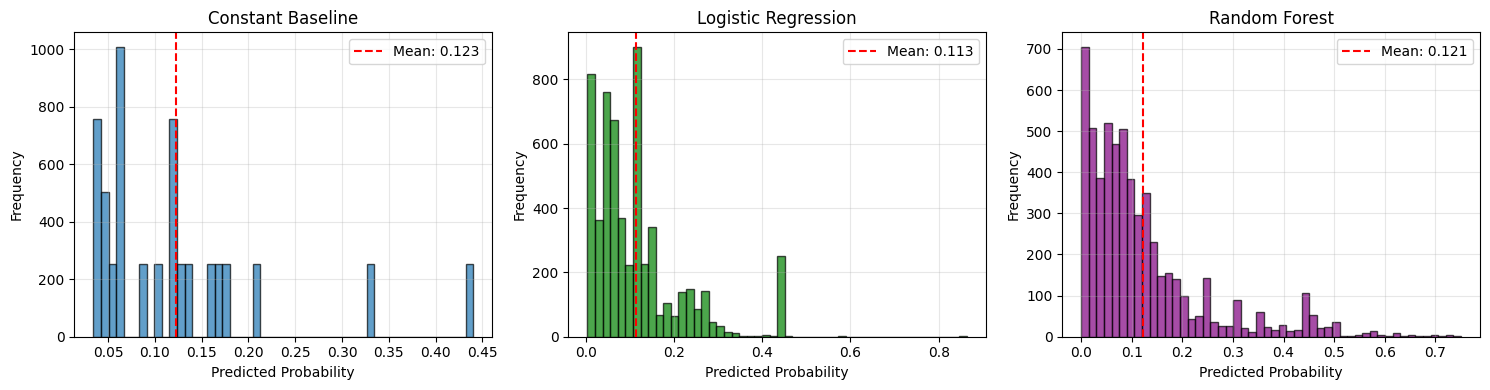


Saved prediction distributions plot to: C:\Users\junio\Documents\TU821-4\FINAL YEAR PROJECT\figures\04_^NDX_prediction_distributions.png


In [35]:
# Predicted probability distributions
print("=" * 60)
print("PREDICTED PROBABILITY DISTRIBUTIONS")
print("=" * 60)

# Extract all predictions from results DataFrames
constant_predictions = constant_df['predicted_prob'].values
logistic_predictions = logistic_df['predicted_prob'].values
rf_predictions = rf_df['predicted_prob'].values

# For constant baseline
print("\nConstant predictions:")
print(f"  Mean: {constant_predictions.mean():.4f}")
print(f"  Std:  {constant_predictions.std():.4f}")
print(f"  Min:  {constant_predictions.min():.4f}")
print(f"  Max:  {constant_predictions.max():.4f}")
print(f"  25th percentile: {np.percentile(constant_predictions, 25):.4f}")
print(f"  50th percentile (median): {np.percentile(constant_predictions, 50):.4f}")
print(f"  75th percentile: {np.percentile(constant_predictions, 75):.4f}")

# For logistic
print("\nLogistic predictions:")
print(f"  Mean: {logistic_predictions.mean():.4f}")
print(f"  Std:  {logistic_predictions.std():.4f}")
print(f"  Min:  {logistic_predictions.min():.4f}")
print(f"  Max:  {logistic_predictions.max():.4f}")
print(f"  25th percentile: {np.percentile(logistic_predictions, 25):.4f}")
print(f"  50th percentile (median): {np.percentile(logistic_predictions, 50):.4f}")
print(f"  75th percentile: {np.percentile(logistic_predictions, 75):.4f}")

# For RF
print("\nRF predictions:")
print(f"  Mean: {rf_predictions.mean():.4f}")
print(f"  Std:  {rf_predictions.std():.4f}")
print(f"  Min:  {rf_predictions.min():.4f}")
print(f"  Max:  {rf_predictions.max():.4f}")
print(f"  25th percentile: {np.percentile(rf_predictions, 25):.4f}")
print(f"  50th percentile (median): {np.percentile(rf_predictions, 50):.4f}")
print(f"  75th percentile: {np.percentile(rf_predictions, 75):.4f}")

# Plot distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(constant_predictions, bins=50, alpha=0.7, edgecolor='black')
axes[0].set_title('Constant Baseline')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Frequency')
axes[0].axvline(constant_predictions.mean(), color='red', linestyle='--', label=f'Mean: {constant_predictions.mean():.3f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(logistic_predictions, bins=50, alpha=0.7, edgecolor='black', color='green')
axes[1].set_title('Logistic Regression')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Frequency')
axes[1].axvline(logistic_predictions.mean(), color='red', linestyle='--', label=f'Mean: {logistic_predictions.mean():.3f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].hist(rf_predictions, bins=50, alpha=0.7, edgecolor='black', color='purple')
axes[2].set_title('Random Forest')
axes[2].set_xlabel('Predicted Probability')
axes[2].set_ylabel('Frequency')
axes[2].axvline(rf_predictions.mean(), color='red', linestyle='--', label=f'Mean: {rf_predictions.mean():.3f}')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
fig_path = save_fig(f"04_{symbol}_prediction_distributions")
plt.show()
print(f"\nSaved prediction distributions plot to: {fig_path}")


## 6.3. Random Forest Feature Importances


### Random Forest Feature Importances

Examines which features the Random Forest relies on most heavily across all walk-forward folds.

**Why it is needed:** Feature importance provides interpretability — understanding WHY the model predicts drawdowns is essential for the thesis narrative. If VIX and volatility features dominate, it confirms the theoretical motivation. If lagged returns dominate, it suggests momentum/mean-reversion effects are primary.

**Methodological note:** Gini-based importance can be biased toward high-cardinality features. However, since all features are continuous and similarly scaled, this bias is minimal here.

**Thesis context:** This analysis directly feeds into the discussion chapter, validating whether the theoretically-motivated features (from Chapter 1's literature review) are actually used by the model.

RANDOM FOREST FEATURE IMPORTANCES

Average feature importances across 23 folds:
------------------------------------------------------------
                   Feature  Importance
                       VIX    0.094033
                 log_close    0.090765
                 ret_lag_5    0.074781
             VIX_5d_change    0.073316
           realized_vol_5d    0.072407
                 ret_lag_4    0.069817
                 ret_lag_1    0.067154
          VIX_change_lag_3    0.066963
                   log_ret    0.065607
          VIX_change_lag_1    0.063829
                 ret_lag_3    0.063173
                 ret_lag_2    0.059490
          VIX_change_lag_2    0.059313
       ret_lag_1_x_VIX_low    0.025208
 realized_vol_5d_x_VIX_low    0.021937
realized_vol_5d_x_VIX_high    0.018399
      ret_lag_1_x_VIX_high    0.013807
           VIX_regime_high    0.000000
            VIX_regime_low    0.000000
            VIX_regime_med    0.000000
----------------------------------------

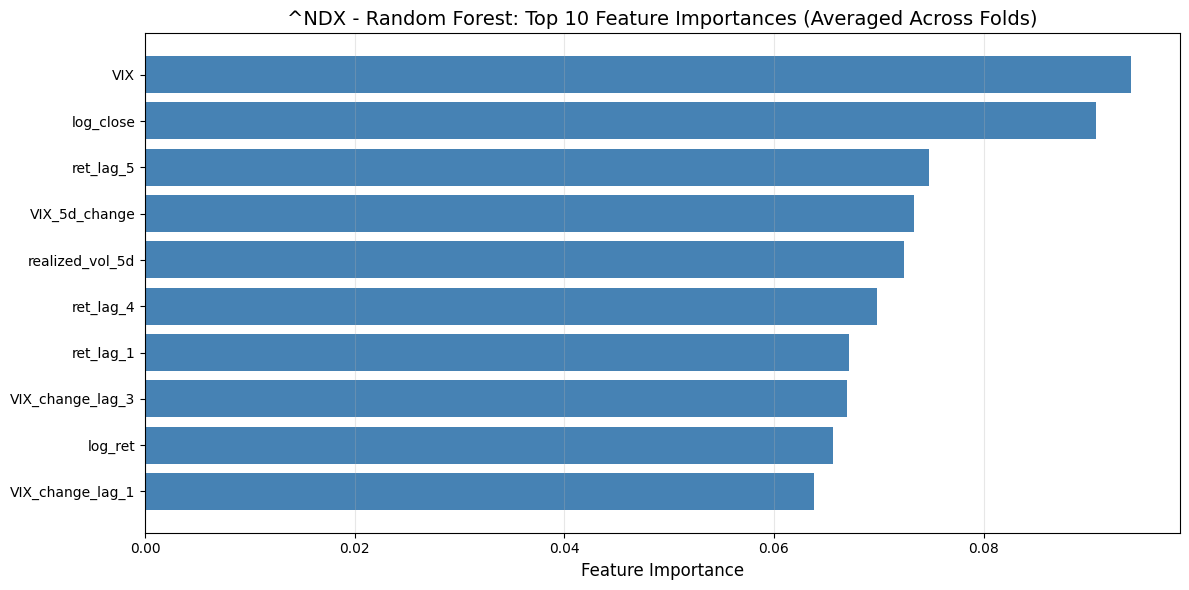


Saved feature importances plot to: C:\Users\junio\Documents\TU821-4\FINAL YEAR PROJECT\figures\04_^NDX_rf_feature_importances.png

Sanity Check - Do top features make sense?
  Expected important features for downside risk prediction:
    - VIX-related features (fear gauge)
    - Volatility measures (realized_vol_5d)
    - Recent returns (ret_lag_1, ret_lag_2, etc.)
    - VIX change lags (momentum in fear)

  Top 5 features: VIX, log_close, ret_lag_5, VIX_5d_change, realized_vol_5d
  VIX features in top 5: 2 (VIX, VIX_5d_change)
  Volatility features in top 5: 1 (realized_vol_5d)
  Return features in top 5: 1 (ret_lag_5)


In [36]:
# Random Forest Feature Importances
print("=" * 60)
print("RANDOM FOREST FEATURE IMPORTANCES")
print("=" * 60)

if len(rf_feature_importances) > 0:
    # Average feature importances across all folds
    # Get feature names from feature_cols (defined in Cell 3)
    n_features = len(feature_cols)
    
    # Initialize importance array
    avg_importances = np.zeros(n_features)
    
    # Sum importances across all folds
    for imp_dict in rf_feature_importances:
        if len(imp_dict['importances']) == n_features:
            avg_importances += imp_dict['importances']
    
    # Average
    avg_importances = avg_importances / len(rf_feature_importances)
    
    # Create DataFrame for easy viewing
    importance_df = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': avg_importances
    }).sort_values('Importance', ascending=False)
    
    print(f"\nAverage feature importances across {len(rf_feature_importances)} folds:")
    print("-" * 60)
    print(importance_df.to_string(index=False))
    print("-" * 60)
    
    # Top 5-10 features
    top_n = min(10, len(importance_df))
    top_features = importance_df.head(top_n)
    
    print(f"\nTop {top_n} Most Important Features:")
    print("-" * 60)
    for idx, row in top_features.iterrows():
        print(f"  {row['Feature']:25s}: {row['Importance']:.4f} ({row['Importance']/avg_importances.sum()*100:.1f}%)")
    print("-" * 60)
    
    # Interpretation
    print("\nInterpretation:")
    print("  Higher importance = feature contributes more to predictions")
    print("  Features are ranked by average importance across all walk-forward folds")
    print("  This shows which features the Random Forest relies on most")
    
    # Plot feature importances
    fig, ax = plt.subplots(figsize=(12, 6))
    top_10 = importance_df.head(10)
    ax.barh(range(len(top_10)), top_10['Importance'].values, color='steelblue')
    ax.set_yticks(range(len(top_10)))
    ax.set_yticklabels(top_10['Feature'].values)
    ax.set_xlabel('Feature Importance', fontsize=12)
    ax.set_title(f'{symbol} - Random Forest: Top 10 Feature Importances (Averaged Across Folds)', fontsize=14)
    ax.grid(True, alpha=0.3, axis='x')
    plt.gca().invert_yaxis()  # Highest importance at top
    plt.tight_layout()
    fig_path = save_fig(f"04_{symbol}_rf_feature_importances")
    plt.show()
    print(f"\nSaved feature importances plot to: {fig_path}")
    
    # Check if top features make sense
    print("\nSanity Check - Do top features make sense?")
    print("  Expected important features for downside risk prediction:")
    print("    - VIX-related features (fear gauge)")
    print("    - Volatility measures (realized_vol_5d)")
    print("    - Recent returns (ret_lag_1, ret_lag_2, etc.)")
    print("    - VIX change lags (momentum in fear)")
    
    top_5_names = top_features.head(5)['Feature'].tolist()
    print(f"\n  Top 5 features: {', '.join(top_5_names)}")
    
    # Check if expected features are in top 5
    vix_features = [f for f in top_5_names if 'VIX' in f]
    vol_features = [f for f in top_5_names if 'vol' in f.lower()]
    ret_features = [f for f in top_5_names if 'ret' in f.lower()]
    
    print(f"  VIX features in top 5: {len(vix_features)} ({', '.join(vix_features) if vix_features else 'None'})")
    print(f"  Volatility features in top 5: {len(vol_features)} ({', '.join(vol_features) if vol_features else 'None'})")
    print(f"  Return features in top 5: {len(ret_features)} ({', '.join(ret_features) if ret_features else 'None'})")
    
else:
    print("No feature importances available (Random Forest may not have been trained)")


### Fold-by-Fold Brier Score Comparison

The core results table: compares Brier scores across all three baselines for each walk-forward fold.

**Why it is needed:** Aggregate (mean) Brier scores can hide important dynamics. A model might be great in calm periods but terrible during crises (or vice versa). Fold-level comparison reveals:
- Whether improvements are consistent across time periods
- Which market regimes are hardest to predict
- Whether variance in performance is acceptable

**Visualisation:** The difference plot (bottom) shows pairwise Brier score differences over time. Negative values mean the more complex model outperforms.

**Statistical significance:** With only a handful of folds, formal significance tests are unreliable. Instead, consistency of improvement direction across folds is the primary evidence.

FOLD-BY-FOLD BRIER SCORES

Total splits processed:
  Constant baseline: 23 splits
  Logistic Regression: 23 splits
  Random Forest: 23 splits

Splits processed by all models: 23
Brier Score per Fold (with date ranges):
------------------------------------------------------------------------------------------------------------------------
 Fold Train_Start  Train_End  Val_Start    Val_End  Constant  Logistic  Random_Forest
    0  2000-01-03 2003-01-07 2003-01-08 2004-01-07  0.206457  0.205611       0.200049
    1  2001-01-02 2004-01-07 2004-01-08 2005-01-06  0.130854  0.093347       0.090168
    2  2002-01-08 2005-01-06 2005-01-07 2006-01-06  0.058028  0.026821       0.029773
    3  2003-01-08 2006-01-06 2006-01-09 2007-01-09  0.031832  0.031471       0.031644
    4  2004-01-08 2007-01-09 2007-01-10 2008-01-09  0.063681  0.063346       0.064233
    5  2005-01-07 2008-01-09 2008-01-10 2009-01-08  0.245750  0.240025       0.212191
    6  2006-01-09 2009-01-08 2009-01-09 2010-01-08  0.1258

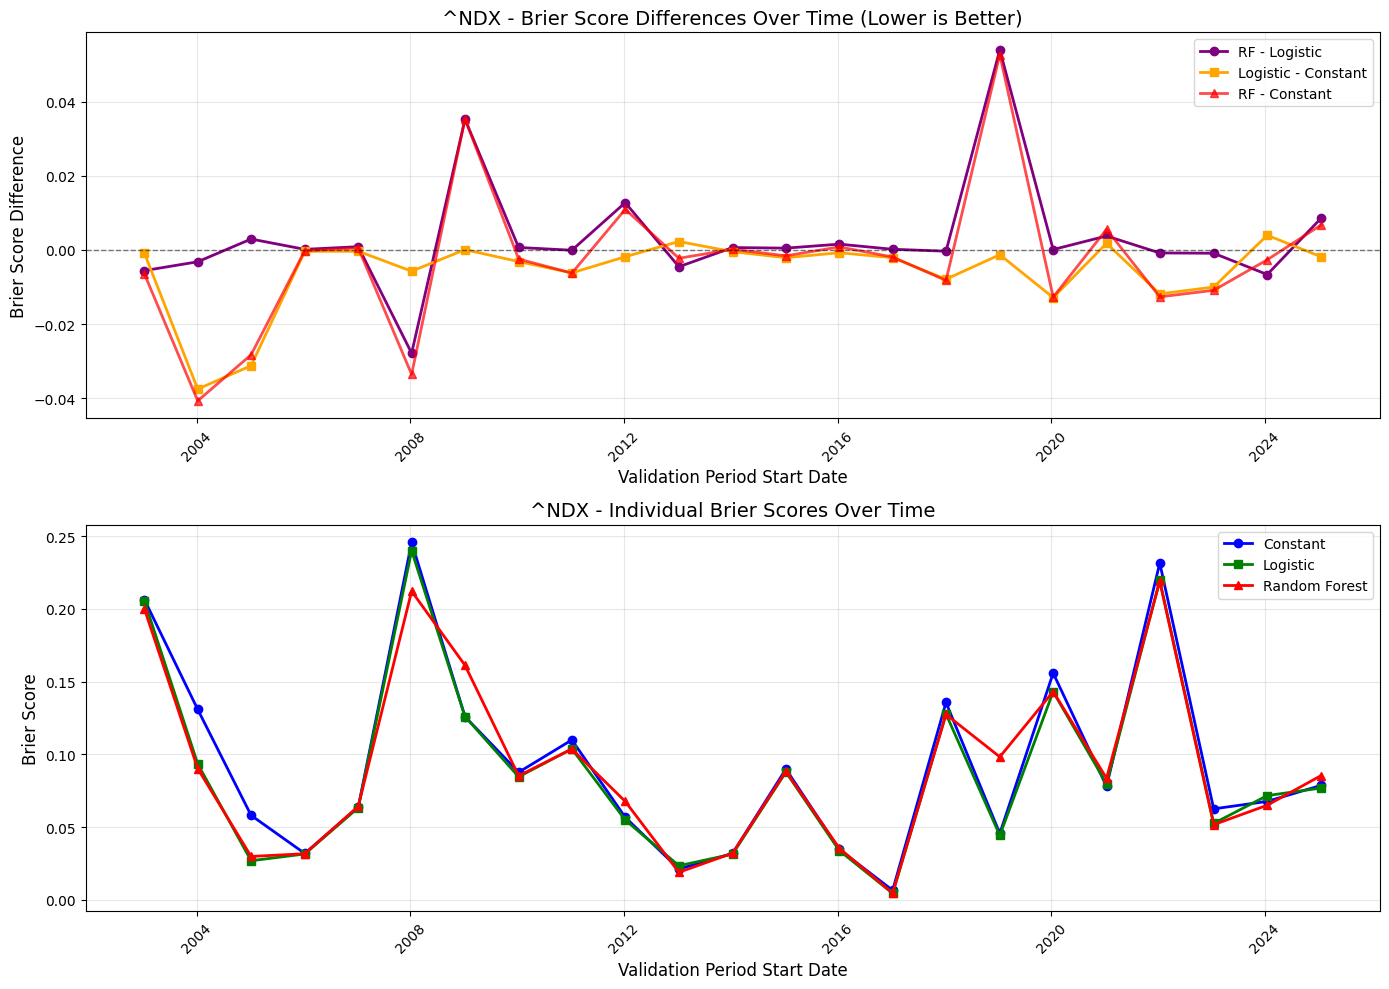

Saved Brier score differences plot to: C:\Users\junio\Documents\TU821-4\FINAL YEAR PROJECT\figures\04_^NDX_brier_differences.png

Interpretation:
  Top plot: Differences between models (negative = better than reference)
  Bottom plot: Individual Brier scores (lower is better)
  RF - Logistic: Negative means RF is better than Logistic
  Logistic - Constant: Negative means Logistic is better than Constant

BRIER SCORE COMPARISON (Summary)

Baseline Comparison (Brier Score - Mean and Std across splits):
        Model  Mean Brier Score  Std Brier Score  Relative Improvement (%)
     logistic          0.088089         0.062630                  6.029301
random_forest          0.091231         0.059806                  2.676585
     constant          0.093741         0.064341                  0.000000

Interpretation:
  Lower Brier score is better (perfect = 0, worst = 1)
  Mean and Std are computed across 23 common walk-forward splits
  (Some splits were skipped due to insufficient class div

In [37]:

# Print fold-by-fold Brier scores
print("=" * 60)
print("FOLD-BY-FOLD BRIER SCORES")
print("=" * 60)

# Note: Some splits may have been skipped (e.g., only one class in training data)
# We need to align the lists properly using split indices to find common splits

num_splits_total = len(constant_brier_per_split)
num_splits_logistic = len(logistic_brier_per_split)
num_splits_rf = len(rf_brier_per_split)

print(f"\nTotal splits processed:")
print(f"  Constant baseline: {num_splits_total} splits")
print(f"  Logistic Regression: {num_splits_logistic} splits")
print(f"  Random Forest: {num_splits_rf} splits")

# Find splits that were processed by all models
common_splits_set = set(constant_split_indices) & set(logistic_split_indices) & set(rf_split_indices)
common_splits = sorted(list(common_splits_set))
print(f"\nSplits processed by all models: {len(common_splits)}")
if len(common_splits) < num_splits_total:
    skipped = set(constant_split_indices) - common_splits_set
    print(f"  Skipped splits (not in all models): {sorted(list(skipped))}")

# Create dictionaries mapping split_idx to Brier score for easy lookup
constant_brier_dict = {idx: score for idx, score in zip(constant_split_indices, constant_brier_per_split)}
logistic_brier_dict = {idx: score for idx, score in zip(logistic_split_indices, logistic_brier_per_split)}
rf_brier_dict = {idx: score for idx, score in zip(rf_split_indices, rf_brier_per_split)}

# Create a DataFrame for easy viewing with dates (only for common splits)
fold_data = []
for split_idx in common_splits:
    # Use dictionary lookup instead of list indexing to handle skipped splits
    dates = fold_dates_dict.get(split_idx)
    if dates is None:
        continue  # Skip if dates not found for this split
    fold_data.append({
        'Fold': split_idx,
        'Train_Start': dates['train_start'].strftime('%Y-%m-%d'),
        'Train_End': dates['train_end'].strftime('%Y-%m-%d'),
        'Val_Start': dates['val_start'].strftime('%Y-%m-%d'),
        'Val_End': dates['val_end'].strftime('%Y-%m-%d'),
        'Constant': constant_brier_dict[split_idx],
        'Logistic': logistic_brier_dict[split_idx],
        'Random_Forest': rf_brier_dict[split_idx]
    })

fold_results = pd.DataFrame(fold_data)

print("Brier Score per Fold (with date ranges):")
print("-" * 120)
# Print with wider display to show dates
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 12)
print(fold_results.to_string(index=False))
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')
print("-" * 120)

# Extract Brier scores for common splits only
common_constant_scores = [constant_brier_dict[i] for i in common_splits]
common_logistic_scores = [logistic_brier_dict[i] for i in common_splits]
common_rf_scores = [rf_brier_dict[i] for i in common_splits]

# Print means across folds (using common splits only for fair comparison)
print(f"\nMean Brier Score across {len(common_splits)} common folds:")
print(f"  Constant:      {np.mean(common_constant_scores):.6f}")
print(f"  Logistic:      {np.mean(common_logistic_scores):.6f}")
print(f"  Random Forest: {np.mean(common_rf_scores):.6f}")

print(f"\nStd Brier Score across {len(common_splits)} common folds:")
print(f"  Constant:      {np.std(common_constant_scores):.6f}")
print(f"  Logistic:      {np.std(common_logistic_scores):.6f}")
print(f"  Random Forest: {np.std(common_rf_scores):.6f}")

# Plot Brier score differences over time
print("\n" + "=" * 60)
print("PLOTTING BRIER SCORE DIFFERENCES OVER TIME")
print("=" * 60)

# Extract validation start dates for x-axis (only for common splits)
# Use dictionary lookup to handle skipped splits
val_start_dates = [fold_dates_dict[i]['val_start'] for i in common_splits if i in fold_dates_dict]

# Compute differences (only for common splits)
rf_minus_logistic = np.array(common_rf_scores) - np.array(common_logistic_scores)
logistic_minus_constant = np.array(common_logistic_scores) - np.array(common_constant_scores)
rf_minus_constant = np.array(common_rf_scores) - np.array(common_constant_scores)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Brier score differences
ax1.plot(val_start_dates, rf_minus_logistic, 'o-', label='RF - Logistic', linewidth=2, markersize=6, color='purple')
ax1.plot(val_start_dates, logistic_minus_constant, 's-', label='Logistic - Constant', linewidth=2, markersize=6, color='orange')
ax1.plot(val_start_dates, rf_minus_constant, '^-', label='RF - Constant', linewidth=2, markersize=6, color='red', alpha=0.7)
ax1.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax1.set_xlabel('Validation Period Start Date', fontsize=12)
ax1.set_ylabel('Brier Score Difference', fontsize=12)
ax1.set_title(f'{symbol} - Brier Score Differences Over Time (Lower is Better)', fontsize=14)
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Individual Brier scores (only for common splits)
ax2.plot(val_start_dates, common_constant_scores, 'o-', label='Constant', linewidth=2, markersize=6, color='blue')
ax2.plot(val_start_dates, common_logistic_scores, 's-', label='Logistic', linewidth=2, markersize=6, color='green')
ax2.plot(val_start_dates, common_rf_scores, '^-', label='Random Forest', linewidth=2, markersize=6, color='red')
ax2.set_xlabel('Validation Period Start Date', fontsize=12)
ax2.set_ylabel('Brier Score', fontsize=12)
ax2.set_title(f'{symbol} - Individual Brier Scores Over Time', fontsize=14)
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
fig_path = save_fig(f"04_{symbol}_brier_differences")
plt.show()
print(f"Saved Brier score differences plot to: {fig_path}")

print("\nInterpretation:")
print("  Top plot: Differences between models (negative = better than reference)")
print("  Bottom plot: Individual Brier scores (lower is better)")
print("  RF - Logistic: Negative means RF is better than Logistic")
print("  Logistic - Constant: Negative means Logistic is better than Constant")

# Compute Brier score metrics for all baselines
# CRITICAL: Use per-split Brier scores, not per-sample aggregation
print("\n" + "=" * 60)
print("BRIER SCORE COMPARISON (Summary)")
print("=" * 60)

# Create summary from per-split Brier scores (using common splits only for fair comparison)
brier_summary_data = {
    'Model': ['constant', 'logistic', 'random_forest'],
    'Mean Brier Score': [
        np.mean(common_constant_scores),
        np.mean(common_logistic_scores),
        np.mean(common_rf_scores)
    ],
    'Std Brier Score': [
        np.std(common_constant_scores),
        np.std(common_logistic_scores),
        np.std(common_rf_scores)
    ]
}
brier_summary = pd.DataFrame(brier_summary_data)

# Get constant baseline Brier score for relative improvement
constant_brier = brier_summary[brier_summary['Model'] == 'constant']['Mean Brier Score'].values[0]

# Compute relative improvement
brier_summary['Relative Improvement (%)'] = (
    (constant_brier - brier_summary['Mean Brier Score']) / constant_brier * 100
)

# Sort by Brier score (lower is better)
brier_summary = brier_summary.sort_values('Mean Brier Score')

print("\nBaseline Comparison (Brier Score - Mean and Std across splits):")
print("=" * 60)
print(brier_summary.to_string(index=False))
print("=" * 60)

print(f"\nInterpretation:")
print(f"  Lower Brier score is better (perfect = 0, worst = 1)")
print(f"  Mean and Std are computed across {len(common_splits)} common walk-forward splits")
print(f"  (Some splits were skipped due to insufficient class diversity in training data)")
print(f"  Constant baseline Brier score: {constant_brier:.6f}")
print(f"  Best model: {brier_summary.iloc[0]['Model']} (Brier = {brier_summary.iloc[0]['Mean Brier Score']:.6f})")
print(f"  Relative improvement vs constant: {brier_summary.iloc[0]['Relative Improvement (%)']:.2f}%")

# Aggregate all results for calibration plots (still need per-sample for plots)
all_results = pd.concat([constant_df, logistic_df, rf_df], ignore_index=True)


## 7. Calibration Plots (Reliability Curves)


### Calibration Plots (Reliability Curves)

Plots reliability diagrams showing predicted probability vs. observed event frequency.

**How to read:** 
- X-axis: Model's predicted probability (binned)
- Y-axis: Actual event rate within that bin
- Perfect calibration: points on the diagonal

**Why it is needed:** Brier score combines calibration and discrimination. A model could have a good Brier score by being well-calibrated (accurate probabilities) even with weak discrimination (can't distinguish events from non-events well). The reliability curve separates these two components.

**Thesis context:** For a risk estimation system, calibration is arguably more important than discrimination. A well-calibrated model saying "12% chance of drawdown" is directly actionable; a poorly-calibrated model giving meaningless probability numbers is not.

**What to look for:**
- Constant baseline: Should be perfectly calibrated at one point (it predicts the overall rate)
- Logistic/RF: Should track the diagonal — deviation reveals systematic over/under-confidence

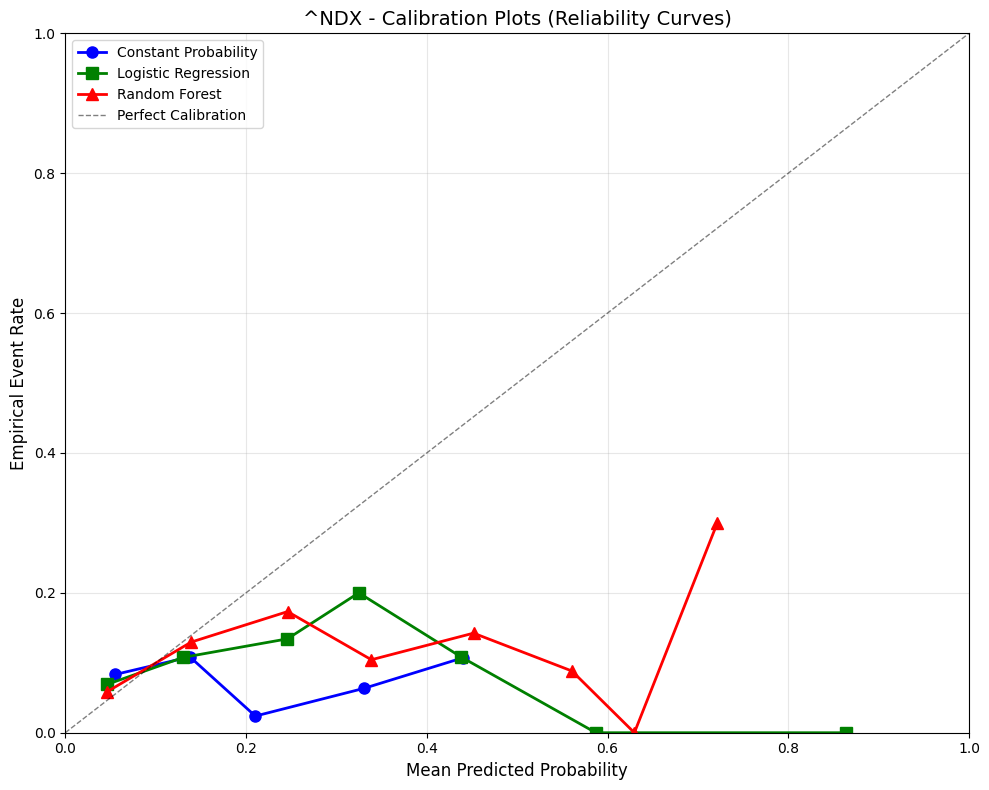

Saved calibration plot to: C:\Users\junio\Documents\TU821-4\FINAL YEAR PROJECT\figures\04_^NDX_calibration.png

Calibration interpretation:
  Perfect calibration = points lie on diagonal line
  Points above diagonal = model underconfident (predicts too low)
  Points below diagonal = model overconfident (predicts too high)


In [38]:
# Calibration plots: reliability curves
# Shows if predicted probabilities match empirical event rates

def compute_calibration_curve(predicted, actual, n_bins=10):
    """Compute calibration curve: predicted vs empirical probabilities."""
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_indices = np.digitize(predicted, bin_edges) - 1
    bin_indices = np.clip(bin_indices, 0, n_bins - 1)
    
    mean_predicted = []
    mean_actual = []
    counts = []
    
    for i in range(n_bins):
        mask = (bin_indices == i)
        if mask.sum() > 0:
            mean_predicted.append(predicted[mask].mean())
            mean_actual.append(actual[mask].mean())
            counts.append(mask.sum())
        else:
            mean_predicted.append(np.nan)
            mean_actual.append(np.nan)
            counts.append(0)
    
    return np.array(mean_predicted), np.array(mean_actual), np.array(counts)

# Helper function to save figures
def save_fig(name: str, dpi: int = 150):
    """Save current matplotlib figure to figures/ directory."""
    if not name.lower().endswith(".png"):
        name = f"{name}.png"
    out = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(out, dpi=dpi, bbox_inches="tight")
    return out

# Create calibration plot for all baselines
fig, ax = plt.subplots(figsize=(10, 8))

model_names = ['constant', 'logistic', 'random_forest']
model_labels = ['Constant Probability', 'Logistic Regression', 'Random Forest']
colors = ['blue', 'green', 'red']
markers = ['o', 's', '^']

for model_name, label, color, marker in zip(model_names, model_labels, colors, markers):
    model_data = all_results[all_results['model_name'] == model_name]
    predicted = model_data['predicted_prob'].values
    actual = model_data['actual_label'].values
    
    mean_pred, mean_actual, counts = compute_calibration_curve(predicted, actual, n_bins=10)
    
    # Plot only bins with data
    valid_mask = ~np.isnan(mean_pred)
    ax.plot(mean_pred[valid_mask], mean_actual[valid_mask], 
            marker=marker, label=label, color=color, linewidth=2, markersize=8)

# Perfect calibration line (diagonal)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Perfect Calibration')

ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Empirical Event Rate', fontsize=12)
ax.set_title(f'{symbol} - Calibration Plots (Reliability Curves)', fontsize=14)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

fig_path = save_fig(f"04_{symbol}_calibration")
plt.show()
print(f"Saved calibration plot to: {fig_path}")

print("\nCalibration interpretation:")
print("  Perfect calibration = points lie on diagonal line")
print("  Points above diagonal = model underconfident (predicts too low)")
print("  Points below diagonal = model overconfident (predicts too high)")


## 8. Results Summary and Interpretation


### Results Summary and Interpretation

Synthesises all baseline results into a narrative interpretation for the thesis.

**Key questions answered:**
1. Is the problem non-trivial? (Do baselines beat the constant?)
2. Is the problem linearly separable? (Does logistic beat constant significantly?)
3. Do nonlinear interactions help? (Does RF beat logistic?)
4. What Brier score must the GRU beat to be justified?

**Thesis context:** This cell directly produces the content for the results chapter. The "GRU target" Brier score becomes the acceptance criterion for notebook 05.

In [39]:
# Comprehensive results summary
print("=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)

print("\nBaseline Performance Comparison:")
print(brier_summary.to_string(index=False))

print("\n" + "=" * 60)
print("INTERPRETATION")
print("=" * 60)

best_model = brier_summary.iloc[0]
constant_brier_val = constant_brier
logistic_brier_val = brier_summary[brier_summary['Model'] == 'logistic']['Mean Brier Score'].values[0]
rf_brier_val = brier_summary[brier_summary['Model'] == 'random_forest']['Mean Brier Score'].values[0]

print(f"\n1. Best Baseline: {best_model['Model']}")
print(f"   Brier Score: {best_model['Mean Brier Score']:.6f}")
print(f"   Improvement vs constant: {best_model['Relative Improvement (%)']:.2f}%")

print(f"\n2. Constant Baseline (Floor):")
print(f"   Brier Score: {constant_brier_val:.6f}")
print(f"   This is the minimum bar - any model must beat this")

print(f"\n3. Logistic Regression:")
print(f"   Brier Score: {logistic_brier_val:.6f}")
logistic_improvement = (constant_brier_val - logistic_brier_val) / constant_brier_val * 100
print(f"   Improvement vs constant: {logistic_improvement:.2f}%")
if logistic_improvement > 0:
    print(f"   ✓ Features are informative (logistic beats constant)")
    print(f"   ✓ Problem may be partially linearly separable")
else:
    print(f"   ✗ Features may not be informative (logistic doesn't beat constant)")

print(f"\n4. Random Forest:")
print(f"   Brier Score: {rf_brier_val:.6f}")
rf_improvement = (constant_brier_val - rf_brier_val) / constant_brier_val * 100
print(f"   Improvement vs constant: {rf_improvement:.2f}%")
rf_vs_logistic = (logistic_brier_val - rf_brier_val) / logistic_brier_val * 100
if rf_vs_logistic > 0:
    print(f"   ✓ Nonlinear interactions help (RF beats logistic by {rf_vs_logistic:.2f}%)")
    print(f"   ✓ Problem is not fully linearly separable")
else:
    print(f"   → Nonlinear interactions don't help much (RF similar to logistic)")

print(f"\n5. Problem Difficulty Assessment:")
if best_model['Mean Brier Score'] < constant_brier_val * 0.9:
    print(f"   ✓ Problem is non-trivial (best baseline significantly better than constant)")
    print(f"   ✓ GRU has room to improve and must earn its keep")
elif best_model['Mean Brier Score'] < constant_brier_val * 0.95:
    print(f"   → Problem is moderately difficult")
    print(f"   → GRU should show clear improvement to be justified")
else:
    print(f"   ⚠ Problem may be too easy (baselines close to constant)")
    print(f"   ⚠ GRU must show substantial improvement")

print(f"\n6. GRU Justification:")
print(f"   The GRU must beat the best baseline ({best_model['Model']})")
print(f"   Current best Brier score: {best_model['Mean Brier Score']:.6f}")
print(f"   GRU target: < {best_model['Mean Brier Score']:.6f} (lower is better)")
print(f"   If GRU can't beat this, it's unjustified and overkill")


RESULTS SUMMARY

Baseline Performance Comparison:
        Model  Mean Brier Score  Std Brier Score  Relative Improvement (%)
     logistic          0.088089         0.062630                  6.029301
random_forest          0.091231         0.059806                  2.676585
     constant          0.093741         0.064341                  0.000000

INTERPRETATION

1. Best Baseline: logistic
   Brier Score: 0.088089
   Improvement vs constant: 6.03%

2. Constant Baseline (Floor):
   Brier Score: 0.093741
   This is the minimum bar - any model must beat this

3. Logistic Regression:
   Brier Score: 0.088089
   Improvement vs constant: 6.03%
   ✓ Features are informative (logistic beats constant)
   ✓ Problem may be partially linearly separable

4. Random Forest:
   Brier Score: 0.091231
   Improvement vs constant: 2.68%
   → Nonlinear interactions don't help much (RF similar to logistic)

5. Problem Difficulty Assessment:
   → Problem is moderately difficult
   → GRU should show clear im

## 9. Save Results


### Save Baseline Results

Saves all predictions, metrics, and summary statistics to disk for later comparison with GRU results.

**What is saved:**
- `baselines_{symbol}.parquet`: Full prediction results (date, predicted_prob, actual_label, model_name, split_index)
- `baselines_{symbol}_summary.txt`: Human-readable summary with interpretation

**Why it is needed:** Notebook 05 (GRU) will load these results to produce side-by-side comparisons and determine whether the GRU achieves statistically meaningful improvement over the best baseline.

In [40]:
# Save baseline results
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Save all predictions and metrics
output_path = RESULTS_DIR / f"baselines_{symbol}.parquet"
df_to_save = all_results.reset_index(drop=True)

# Try fastparquet engine
saved = False
try:
    df_to_save.to_parquet(output_path, index=False, engine='fastparquet')
    print("Saved using fastparquet engine")
    saved = True
except (ImportError, Exception) as e:
    print(f"fastparquet not available: {e}")

# If parquet save failed, use pickle as reliable fallback
if not saved:
    print("\nNote: Parquet save unavailable. Using pickle format instead.")
    output_path = RESULTS_DIR / f"baselines_{symbol}.pkl"
    all_results.to_pickle(output_path)
    print(f"Saved to pickle format: {output_path}")

print(f"\nBaseline results saved to: {output_path}")
print(f"  Total predictions: {len(all_results)}")
print(f"  Models: {all_results['model_name'].unique().tolist()}")
print(f"  Splits: {all_results['split_index'].nunique()}")
if output_path.exists():
    print(f"  File size: {output_path.stat().st_size / 1024 / 1024:.2f} MB")

# Save summary metrics
summary_path = RESULTS_DIR / f"baselines_{symbol}_summary.txt"
with open(summary_path, 'w') as f:
    f.write("=" * 60 + "\n")
    f.write("BASELINE RESULTS SUMMARY\n")
    f.write("=" * 60 + "\n\n")
    f.write(brier_summary.to_string(index=False))
    f.write("\n\n")
    f.write("=" * 60 + "\n")
    f.write("INTERPRETATION\n")
    f.write("=" * 60 + "\n")
    f.write(f"\nBest baseline: {best_model['Model']}\n")
    f.write(f"Brier score: {best_model['Mean Brier Score']:.6f}\n")
    f.write(f"GRU must beat this to be justified.\n")

print(f"\nSummary saved to: {summary_path}")

print("\n" + "=" * 60)
print("✓ BASELINES COMPLETE")
print("=" * 60)
print(f"Results saved to: {output_path}")
print(f"Calibration plot saved to: {FIG_DIR}")
print(f"\nThe bar is set. GRU must beat: {best_model['Model']} (Brier = {best_model['Mean Brier Score']:.6f})")


Saved using fastparquet engine

Baseline results saved to: C:\Users\junio\Documents\TU821-4\FINAL YEAR PROJECT\results\baselines_^NDX.parquet
  Total predictions: 17388
  Models: ['constant', 'logistic', 'random_forest']
  Splits: 23
  File size: 0.29 MB

Summary saved to: C:\Users\junio\Documents\TU821-4\FINAL YEAR PROJECT\results\baselines_^NDX_summary.txt

✓ BASELINES COMPLETE
Results saved to: C:\Users\junio\Documents\TU821-4\FINAL YEAR PROJECT\results\baselines_^NDX.parquet
Calibration plot saved to: C:\Users\junio\Documents\TU821-4\FINAL YEAR PROJECT\figures

The bar is set. GRU must beat: logistic (Brier = 0.088089)
